In [17]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
import io

In [18]:
# Load data, extract the primary tactic per CVE, filter to top 5 most common tactics
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='KEV Enriched')
print(f"Loaded {len(df)} rows")

# Extract first-listed tactic per CVE
df['tactic'] = df['Tactic(s)'].fillna('Unknown').str.split('; ').str[0].str.strip()

# Only keep the 4 real tactic classes with enough data to learn from
valid_tactics = ['Initial Access', 'Defense Evasion', 'Execution', 'Credential Access']
df = df[df['tactic'].isin(valid_tactics)].copy()
print(f"Filtered to {len(df)} rows")
print(df['tactic'].value_counts())

Saving sample.xlsx to sample (2).xlsx
Loaded 1539 rows
Filtered to 974 rows
tactic
Initial Access       572
Defense Evasion      189
Execution            176
Credential Access     37
Name: count, dtype: int64


In [19]:
# Limit CWE to top 10 most common — rare CWEs act like perfect identifiers and inflate accuracy
df['has_windows'] = df['Platform(s)'].astype(str).str.contains('Windows').astype(int)
df['has_linux']   = df['Platform(s)'].astype(str).str.contains('Linux').astype(int)
df['has_network'] = df['Platform(s)'].astype(str).str.contains('Network').astype(int)
df['has_cloud']   = df['Platform(s)'].astype(str).str.contains('SaaS|IaaS|Azure|Office 365').astype(int)
df['platform_count'] = df['Platform(s)'].astype(str).str.split(';').apply(len)

# CWE: extract type ID and one-hot encode top 20 most common
df['cwe'] = df['CWE(s)'].astype(str).str.extract(r'(CWE-\d+)')[0].fillna('Unknown')
top_cwes = df['cwe'].value_counts().nlargest(20).index
df['cwe_encoded'] = df['cwe'].where(df['cwe'].isin(top_cwes), other='Other')

# Year added and number of ATT&CK techniques mapped
df['year'] = pd.to_datetime(df['Date Added'], errors='coerce').dt.year.fillna(2022).astype(int)
df['technique_count'] = df['ATT&CK ID(s)'].fillna('').astype(str).apply(
    lambda x: len([t for t in x.split(';') if t.strip()]) if x else 0
)

# Assemble final feature matrix
cwe_dummies = pd.get_dummies(df['cwe_encoded'], prefix='cwe')
features = pd.concat([
    df[['has_windows','has_linux','has_network','has_cloud','platform_count','year','technique_count']],
    cwe_dummies
], axis=1)

# Encode tactic labels as integers
le = LabelEncoder()
labels = le.fit_transform(df['tactic'])

print(f"Feature matrix shape: {features.shape}")
for i, c in enumerate(le.classes_):
    print(f"  [{i}] {c}: {(df['tactic']==c).sum()} rows")

Feature matrix shape: (974, 28)
  [0] Credential Access: 37 rows
  [1] Defense Evasion: 189 rows
  [2] Execution: 176 rows
  [3] Initial Access: 572 rows


In [20]:
# Split into 80% train / 20% test, then scale features for Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# Check what accuracy looks like just by always guessing the most common class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline = dummy.score(X_test, y_test)
print(f"Majority class baseline: {baseline:.1%}  ← the floor our model needs to beat")

# Logistic Regression requires scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Majority class baseline: 59.0%  ← the floor our model needs to beat


In [21]:
# Train the Logistic Regression model, run predictions, print accuracy and full report
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.1%}  (baseline was {baseline:.1%})")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 93.8%  (baseline was 59.0%)

Detailed Report:
                   precision    recall  f1-score   support

Credential Access       0.70      1.00      0.82         7
  Defense Evasion       0.94      0.84      0.89        38
        Execution       0.97      0.89      0.93        35
   Initial Access       0.95      0.98      0.97       115

         accuracy                           0.94       195
        macro avg       0.89      0.93      0.90       195
     weighted avg       0.94      0.94      0.94       195



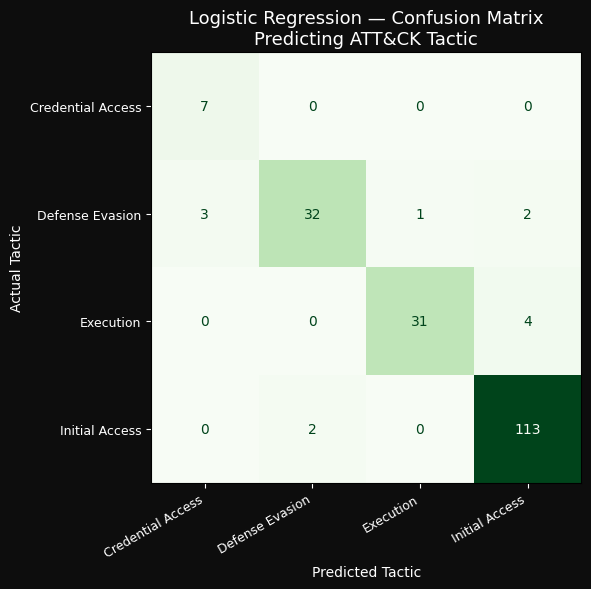

In [22]:
# Confusion matrix: shows which tactics the model predicted correctly vs mixed up
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Logistic Regression — Confusion Matrix\nPredicting ATT&CK Tactic', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
ax.set_xlabel('Predicted Tactic', color='white')
ax.set_ylabel('Actual Tactic', color='white')
plt.xticks(rotation=30, ha='right', color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.savefig('logreg_confusion.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

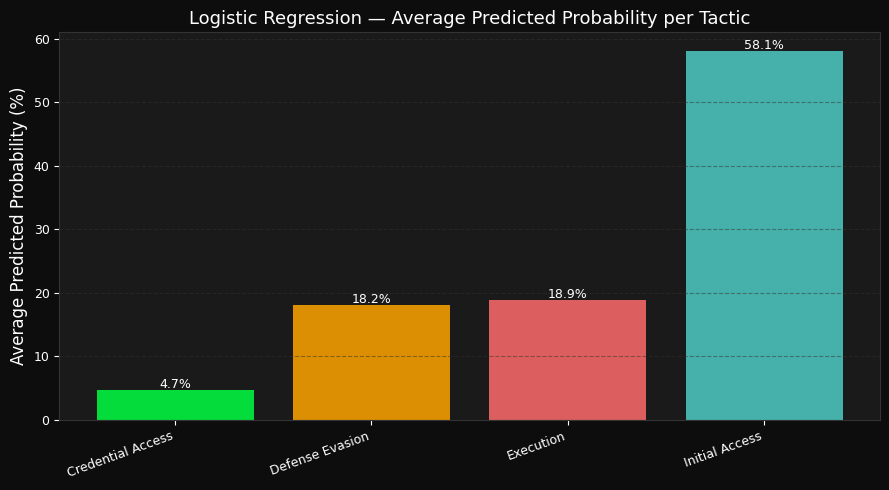

In [23]:
# How confident the model is in each tactic on average across the test set
proba = lr_model.predict_proba(X_test_scaled)
avg_proba = proba.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

colors = ['#00FF41', '#FFA500', '#FF6B6B', '#4ECDC4']
bars = ax.bar(le.classes_, avg_proba * 100, color=colors, alpha=0.85)
ax.set_ylabel('Average Predicted Probability (%)', color='white', fontsize=12)
ax.set_title('Logistic Regression — Average Predicted Probability per Tactic', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=20, ha='right')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
for bar, val in zip(bars, avg_proba):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('logreg_probabilities.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [24]:
# Export probability scores
proba_df = pd.DataFrame(proba, columns=[f'prob_{t}' for t in le.classes_])
proba_df['actual_tactic']    = le.inverse_transform(y_test)
proba_df['predicted_tactic'] = le.inverse_transform(y_pred)
proba_df['correct']          = (y_test == y_pred)
proba_df.to_csv('logreg_probabilities.csv', index=False)

print(f"=== NOTEBOOK 2 SUMMARY ===")
print(f"Model: Logistic Regression (balanced class weights)")
print(f"Features: platform flags, CWE type (top 20), year, technique count")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Majority class baseline: {baseline:.1%}")
print(f"Logistic Regression accuracy: {acc:.1%}")

=== NOTEBOOK 2 SUMMARY ===
Model: Logistic Regression (balanced class weights)
Features: platform flags, CWE type (top 20), year, technique count
Train: 779 | Test: 195
Majority class baseline: 59.0%
Logistic Regression accuracy: 93.8%
